In [84]:
import numpy as np
import pandas as pd 
import scipy as sp
import scipy.signal as spg
import cmath
import scipy.constants as const
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis')
import useful_functions as uf
import seaborn as sns 
sns.set_theme()


## Load in COMSOL results

In [85]:
double_zotefoam = uf.fix_csv('EigenRadiusSweep_Al&_DoubleZotefoamContactModel_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')
just_alumina = uf.fix_csv('EigenRadiusSweep_Al&NO_Zotefoam_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')


In [86]:
just_alumina = uf.fix_csv('EigenRadiusSweep_Al&NO_Zotefoam_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')


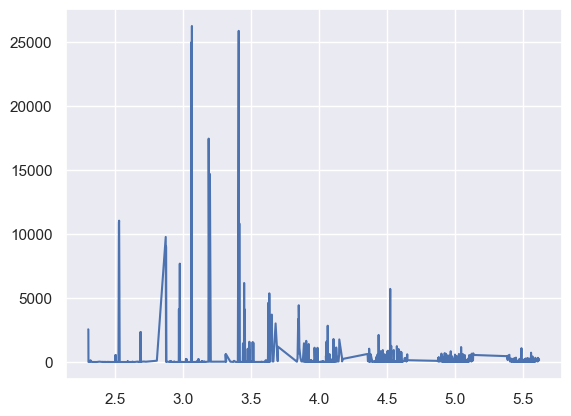

In [87]:
plt.plot(just_alumina['Frequency (GHz)'], just_alumina['Quality factor (1)'])

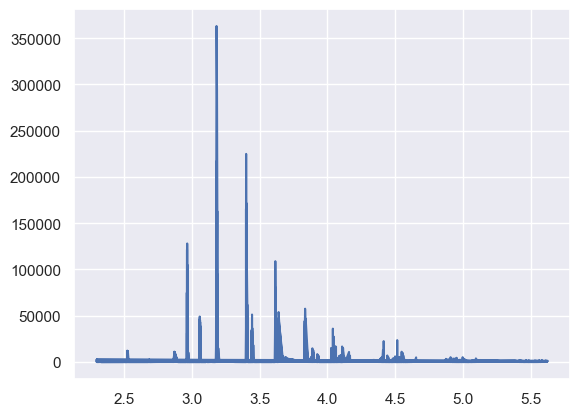

In [88]:
plt.plot(double_zotefoam['Frequency (GHz)'], double_zotefoam['Quality factor (1)'])

## Separate by Radius

In [89]:
quarter_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

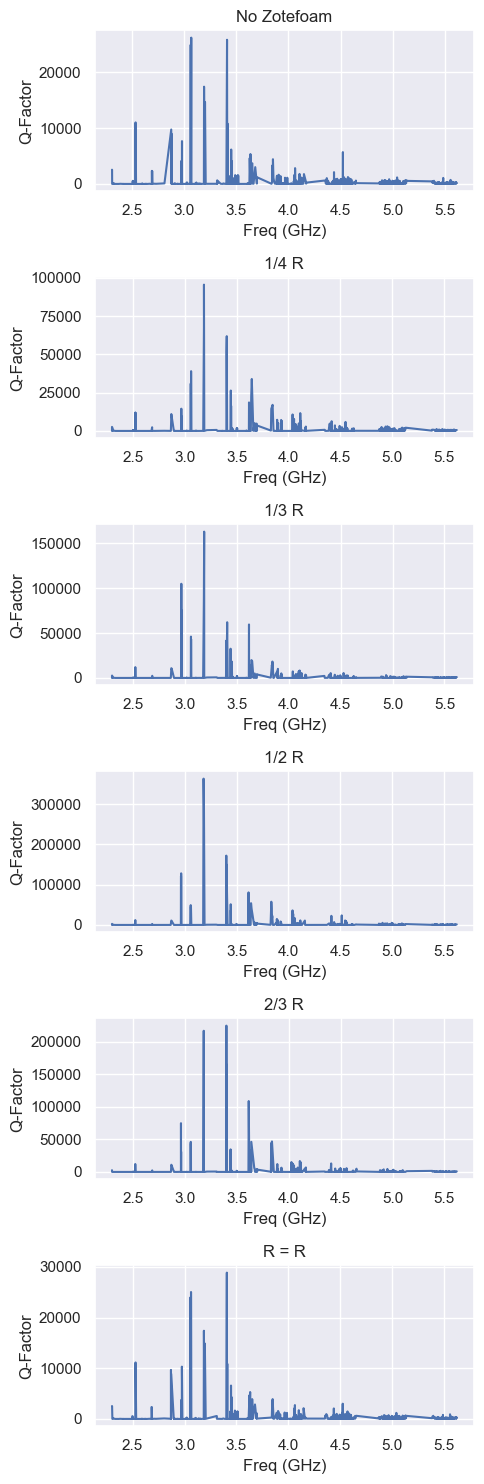

In [90]:
fig, ax = plt.subplots(6, 1, figsize = (5, 15))

ax[0].plot(just_alumina['Frequency (GHz)'], just_alumina['Quality factor (1)'])
ax[0].set_title('No Zotefoam')
ax[0].set_xlabel('Freq (GHz)')
ax[0].set_ylabel('Q-Factor')

ax[1].plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'])
ax[1].set_title('1/4 R')
ax[1].set_xlabel('Freq (GHz)')
ax[1].set_ylabel('Q-Factor')

ax[2].plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'])
ax[2].set_title('1/3 R')
ax[2].set_xlabel('Freq (GHz)')
ax[2].set_ylabel('Q-Factor')

ax[3].plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'])
ax[3].set_title('1/2 R')
ax[3].set_xlabel('Freq (GHz)')
ax[3].set_ylabel('Q-Factor')

ax[4].plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'])
ax[4].set_title('2/3 R')
ax[4].set_xlabel('Freq (GHz)')
ax[4].set_ylabel('Q-Factor')

ax[5].plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'])
ax[5].set_title('R = R')
ax[5].set_xlabel('Freq (GHz)')
ax[5].set_ylabel('Q-Factor')

#plt.setp(ax, xlim=(2.95, 3.5))
plt.tight_layout()


yeah really just need to do a threshold thing rather than the find peaks because it is missing some peaks due to the way that the function works (distance from point next to it) -- it's missing some where there are two eigenvalues that are conjugates

## Get Q-factor Peaks

In [91]:
# dataframes of just the resonances
alumina_peaks = just_alumina[just_alumina['Quality factor (1)']>=3500].reset_index(drop=True).iloc[0:18]
quarter_R_Qpeaks = quarter_R[quarter_R['Quality factor (1)']>=10000].reset_index(drop=True).iloc[0:18]
third_R_Qpeaks = third_R[third_R['Quality factor (1)']>=7000].reset_index(drop=True).iloc[0:18]
half_R_Qpeaks = half_R[half_R['Quality factor (1)']>=10000].reset_index(drop=True).iloc[0:18]
twothirds_R_Qpeaks = twothirds_R[twothirds_R['Quality factor (1)']>=10000].reset_index(drop=True).iloc[0:18]
full_R_Qpeaks = full_R[full_R['Quality factor (1)']>=3000].reset_index(drop=True).iloc[0:18]


# extract frequencies of the mode sets
alumina_peakfreqs = alumina_peaks['Frequency (GHz)'] 
quarter_R_peakfreqs = quarter_R_Qpeaks['Frequency (GHz)']
third_R_peakfreqs = third_R_Qpeaks['Frequency (GHz)']
half_R_peakfreqs = half_R_Qpeaks['Frequency (GHz)']
twothirds_R_peakfreqs = twothirds_R_Qpeaks['Frequency (GHz)']
full_R_peakfreqs = full_R_Qpeaks['Frequency (GHz)']

# verify compatibility
print(len(alumina_peakfreqs), len(quarter_R_peakfreqs), len(third_R_peakfreqs), 
      len(half_R_peakfreqs), len(twothirds_R_peakfreqs), len(full_R_peakfreqs))

18 18 18 18 18 18


In [92]:
radius_column_relative = [0, 1/4, 1/3, 1/2, 2/3, 1]
radius_column_relative_short = [0, 1/4, 1/3, 1/2, 2/3]

radius_column_meters = [0, 0.019056, 0.025408, 0.0381125, 0.050817, 0.076225]
radius_column_meters_short = [0, 0.019056, 0.025408, 0.0381125, 0.050817]



In [104]:
# CREATING DATAFRAMES

# radius column vectors for comparison

# as fraction of alumina disk radius 
radius_column_relative = [0, 1/4, 1/3, 1/2, 2/3, 1]
radius_column_relative_short = [0, 1/4, 1/3, 1/2, 2/3]

# actual zotefoam radius in meters
radius_column_meters = [0, 0.019056, 0.025408, 0.0381125, 0.050817, 0.076225]
radius_column_meters_short = [0, 0.019056, 0.025408, 0.0381125, 0.050817]

# highest-Q resonances
column_names = ['Radius', 
                'TE 2.5 I', 'TE 2.5 II', 
                'TM 2.87 I', 'TM 2.87 II', 
                'TE 2.97 I', 'TE 2.97 II', 
                'TM 3.05 I', 'TM 3.05 II', 
                'TE 3.19 I', 'TE 3.19 II', 
                'TE 3.41 I', 'TE 3.41 II', 
                'TM 3.45 I', 'TM 3.45 II',
                'TE 3.62 I', 'TE 3.62 II', 
                'TM 3.64 I', 'TM 3.64 II']

# dataframe including full R=R zotefoam radius
resonances_df_full = pd.DataFrame([alumina_peakfreqs.values, 
                                   quarter_R_peakfreqs.values, 
                                   third_R_peakfreqs.values, 
                                   half_R_peakfreqs.values, 
                                   twothirds_R_peakfreqs.values, 
                                   full_R_peakfreqs.values])
resonances_df_full.insert(0, 'Radius', radius_column_relative)
resonances_df_full.columns = column_names

# dataframe excluding full R=R zotefoam radius 
resonances_df = pd.DataFrame([alumina_peakfreqs.values, 
                              quarter_R_peakfreqs.values, 
                              third_R_peakfreqs.values, 
                              half_R_peakfreqs.values, 
                              twothirds_R_peakfreqs.values])

resonances_df.insert(0, 'Radius', radius_column_relative_short)
resonances_df.columns = column_names

In [105]:
resonances_df

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.449444,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.525111,2.525538,2.871965,2.873113,2.966250,2.968221,3.058881,3.062315,3.186023,3.186234,3.403163,3.405776,3.444741,3.447684,3.620184,3.624657,3.641323,3.646923
2,0.333333,2.524683,2.525197,2.871180,2.874121,2.966043,2.967495,3.060191,3.061462,3.184366,3.187294,3.400090,3.408665,3.441439,3.453346,3.618681,3.626443,3.642059,3.649120
3,0.500000,2.523918,2.524255,2.870879,2.872502,2.964545,2.966071,3.058371,3.060603,3.182201,3.185843,3.401393,3.402803,3.443970,3.445856,3.615781,3.623937,3.639753,3.645424
4,0.666667,2.523259,2.523624,2.870259,2.871861,2.963390,2.964617,3.057603,3.059370,3.182031,3.182589,3.399465,3.400668,3.440930,3.443851,3.615739,3.619234,3.636692,3.640691


In [106]:
resonances_df_full

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.449444,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.525111,2.525538,2.871965,2.873113,2.966250,2.968221,3.058881,3.062315,3.186023,3.186234,3.403163,3.405776,3.444741,3.447684,3.620184,3.624657,3.641323,3.646923
2,0.333333,2.524683,2.525197,2.871180,2.874121,2.966043,2.967495,3.060191,3.061462,3.184366,3.187294,3.400090,3.408665,3.441439,3.453346,3.618681,3.626443,3.642059,3.649120
3,0.500000,2.523918,2.524255,2.870879,2.872502,2.964545,2.966071,3.058371,3.060603,3.182201,3.185843,3.401393,3.402803,3.443970,3.445856,3.615781,3.623937,3.639753,3.645424
4,0.666667,2.523259,2.523624,2.870259,2.871861,2.963390,2.964617,3.057603,3.059370,3.182031,3.182589,3.399465,3.400668,3.440930,3.443851,3.615739,3.619234,3.636692,3.640691
5,1.000000,2.527198,2.528829,2.869485,2.871688,2.967898,2.974534,3.057049,3.062496,3.186445,3.195425,3.407108,3.411425,3.447324,3.453306,3.625010,3.631537,3.647428,3.651163


In [123]:
# getting delta f vs. radius for resonance shift ALL RELATIVE TO JUST ALUMINA CASE

RFull_deltas = resonances_df_full.iloc[-1, 1:] - resonances_df_full.iloc[0, 1:]
RTwoThirds_deltas = resonances_df.iloc[-1, 1:] - resonances_df.iloc[0, 1:]
Rhalf_deltas = resonances_df.iloc[-2, 1:] - resonances_df.iloc[0, 1:]
Rthird_deltas = resonances_df.iloc[2, 1:] - resonances_df.iloc[0, 1:]
Rquarter_deltas = resonances_df.iloc[1, 1:] - resonances_df.iloc[0, 1:]

radius_deltas = pd.DataFrame([resonances_df.drop(columns=['Radius']).iloc[0], 
                              Rquarter_deltas, 
                              Rthird_deltas, 
                              Rhalf_deltas, 
                              RTwoThirds_deltas], 
                              index=radius_column_relative_short).reset_index().rename(columns={"index": "Radius"})

radius_deltas_full = pd.DataFrame([resonances_df.drop(columns=['Radius']).iloc[0], 
                              Rquarter_deltas, 
                              Rthird_deltas, 
                              Rhalf_deltas, 
                              RTwoThirds_deltas, 
                              RFull_deltas], 
                              index=radius_column_relative).reset_index().rename(columns={"index": "Radius"})

radius_deltas


,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.449444,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,-0.004090,-0.005300,-0.001284,-0.002470,-0.003954,-0.008430,-0.001159,-0.003294,-0.002687,-0.011570,-0.006312,-0.008231,-0.004703,-0.007462,-0.007265,-0.009711,-0.007674,-0.005512
2,0.333333,-0.004518,-0.005640,-0.002069,-0.001461,-0.004161,-0.009156,0.000151,-0.004147,-0.004344,-0.010509,-0.009385,-0.005342,-0.008006,-0.001801,-0.008768,-0.007925,-0.006938,-0.003316
3,0.500000,-0.005283,-0.006582,-0.002370,-0.003080,-0.005659,-0.010580,-0.001669,-0.005005,-0.006509,-0.011960,-0.008082,-0.011204,-0.005474,-0.009291,-0.011669,-0.010431,-0.009244,-0.007011
4,0.666667,-0.005942,-0.007214,-0.002989,-0.003721,-0.006814,-0.012034,-0.002437,-0.006239,-0.006679,-0.015214,-0.010010,-0.013339,-0.008514,-0.011296,-0.011711,-0.015134,-0.012305,-0.011744


In [122]:
radius_deltas_full

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.449444,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,-0.004090,-0.005300,-0.001284,-0.002470,-0.003954,-0.008430,-0.001159,-0.003294,-0.002687,-0.011570,-0.006312,-0.008231,-0.004703,-0.007462,-0.007265,-0.009711,-0.007674,-0.005512
2,0.333333,-0.004518,-0.005640,-0.002069,-0.001461,-0.004161,-0.009156,0.000151,-0.004147,-0.004344,-0.010509,-0.009385,-0.005342,-0.008006,-0.001801,-0.008768,-0.007925,-0.006938,-0.003316
3,0.500000,-0.005283,-0.006582,-0.002370,-0.003080,-0.005659,-0.010580,-0.001669,-0.005005,-0.006509,-0.011960,-0.008082,-0.011204,-0.005474,-0.009291,-0.011669,-0.010431,-0.009244,-0.007011
4,0.666667,-0.005942,-0.007214,-0.002989,-0.003721,-0.006814,-0.012034,-0.002437,-0.006239,-0.006679,-0.015214,-0.010010,-0.013339,-0.008514,-0.011296,-0.011711,-0.015134,-0.012305,-0.011744
5,1.000000,-0.002004,-0.002009,-0.003764,-0.003894,-0.002306,-0.002117,-0.002991,-0.003113,-0.002265,-0.002378,-0.002367,-0.002582,-0.002120,-0.001841,-0.002439,-0.002832,-0.001569,-0.001272


In [231]:
# Drop Radius column for arithmetic
baseline_freqs = resonances_df_full.iloc[0, 1:]

# Compute relative shifts for each row
relative_shifts = (resonances_df_full.iloc[:, 1:] - baseline_freqs) / baseline_freqs

# Add Radius column back in
relative_shifts.insert(0, 'Radius', resonances_df_full['Radius'])

In [232]:
relative_shifts

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.250000,-0.001617,-0.002094,-0.000447,-0.000859,-0.001331,-0.002832,-0.000379,-0.001075,-0.000843,-0.003618,-0.001851,-0.002411,-0.001364,-0.002160,-0.002003,-0.002672,-0.002103,-0.001509
2,0.333333,-0.001786,-0.002229,-0.000720,-0.000508,-0.001401,-0.003076,0.000049,-0.001353,-0.001362,-0.003286,-0.002753,-0.001565,-0.002321,-0.000521,-0.002417,-0.002181,-0.001901,-0.000908
3,0.500000,-0.002089,-0.002601,-0.000825,-0.001071,-0.001905,-0.003554,-0.000545,-0.001633,-0.002041,-0.003740,-0.002370,-0.003282,-0.001587,-0.002689,-0.003217,-0.002870,-0.002533,-0.001920
4,0.666667,-0.002349,-0.002850,-0.001040,-0.001294,-0.002294,-0.004043,-0.000796,-0.002035,-0.002095,-0.004758,-0.002936,-0.003907,-0.002468,-0.003269,-0.003228,-0.004164,-0.003372,-0.003215
5,1.000000,-0.000792,-0.000794,-0.001310,-0.001354,-0.000776,-0.000711,-0.000978,-0.001015,-0.000710,-0.000744,-0.000694,-0.000756,-0.000615,-0.000533,-0.000672,-0.000779,-0.000430,-0.000348


In [224]:
relative_shifts.iloc[0, 1:]

TE 2.5 I      0.0
TE 2.5 II     0.0
TM 2.87 I     0.0
TM 2.87 II    0.0
TE 2.97 I     0.0
TE 2.97 II    0.0
TM 3.05 I     0.0
TM 3.05 II    0.0
TE 3.19 I     0.0
TE 3.19 II    0.0
TE 3.41 I     0.0
TE 3.41 II    0.0
TM 3.45 I     0.0
TM 3.45 II    0.0
TE 3.62 I     0.0
TE 3.62 II    0.0
TM 3.64 I     0.0
TM 3.64 II    0.0
Name: 0, dtype: float64

In [225]:
relative_shifts.iloc[1, 1:]

TE 2.5 I     -0.001617
TE 2.5 II    -0.002094
TM 2.87 I    -0.000447
TM 2.87 II   -0.000859
TE 2.97 I    -0.001331
TE 2.97 II   -0.002832
TM 3.05 I    -0.000379
TM 3.05 II   -0.001075
TE 3.19 I    -0.000843
TE 3.19 II   -0.003618
TE 3.41 I    -0.001851
TE 3.41 II   -0.002411
TM 3.45 I    -0.001364
TM 3.45 II   -0.002160
TE 3.62 I    -0.002003
TE 3.62 II   -0.002672
TM 3.64 I    -0.002103
TM 3.64 II   -0.001509
Name: 1, dtype: float64

In [218]:
relative_shifts

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.250000,-0.001617,-0.002094,-0.000447,-0.000859,-0.001331,-0.002832,-0.000379,-0.001075,-0.000843,-0.003618,-0.001851,-0.002411,-0.001364,-0.002160,-0.002003,-0.002672,-0.002103,-0.001509
2,0.333333,-0.001786,-0.002229,-0.000720,-0.000508,-0.001401,-0.003076,0.000049,-0.001353,-0.001362,-0.003286,-0.002753,-0.001565,-0.002321,-0.000521,-0.002417,-0.002181,-0.001901,-0.000908
3,0.500000,-0.002089,-0.002601,-0.000825,-0.001071,-0.001905,-0.003554,-0.000545,-0.001633,-0.002041,-0.003740,-0.002370,-0.003282,-0.001587,-0.002689,-0.003217,-0.002870,-0.002533,-0.001920
4,0.666667,-0.002349,-0.002850,-0.001040,-0.001294,-0.002294,-0.004043,-0.000796,-0.002035,-0.002095,-0.004758,-0.002936,-0.003907,-0.002468,-0.003269,-0.003228,-0.004164,-0.003372,-0.003215


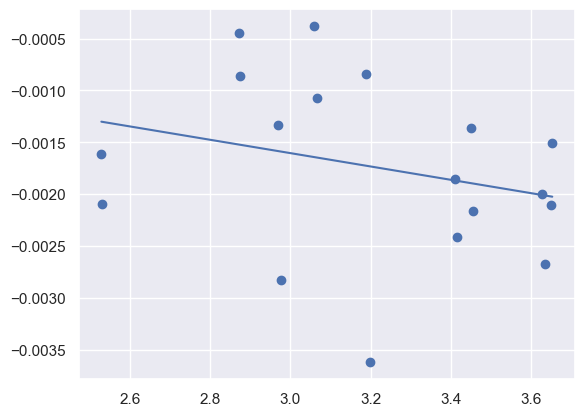

In [ ]:
# fit lines to relative shift points 

# for quarter R
quarter_R_RelShift_slope, quarter_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts.iloc[1, 1:], 1)
quarter_R_RelShift_y_fit = quarter_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + quarter_R_RelShift_int

plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts.iloc[1, 1:], label = '1/4 R')
plt.plot(resonances_df_full.iloc[0, 1:], quarter_R_RelShift_y_fit)



In [238]:
relative_shifts

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.250000,-0.001617,-0.002094,-0.000447,-0.000859,-0.001331,-0.002832,-0.000379,-0.001075,-0.000843,-0.003618,-0.001851,-0.002411,-0.001364,-0.002160,-0.002003,-0.002672,-0.002103,-0.001509
2,0.333333,-0.001786,-0.002229,-0.000720,-0.000508,-0.001401,-0.003076,0.000049,-0.001353,-0.001362,-0.003286,-0.002753,-0.001565,-0.002321,-0.000521,-0.002417,-0.002181,-0.001901,-0.000908
3,0.500000,-0.002089,-0.002601,-0.000825,-0.001071,-0.001905,-0.003554,-0.000545,-0.001633,-0.002041,-0.003740,-0.002370,-0.003282,-0.001587,-0.002689,-0.003217,-0.002870,-0.002533,-0.001920
4,0.666667,-0.002349,-0.002850,-0.001040,-0.001294,-0.002294,-0.004043,-0.000796,-0.002035,-0.002095,-0.004758,-0.002936,-0.003907,-0.002468,-0.003269,-0.003228,-0.004164,-0.003372,-0.003215
5,1.000000,-0.000792,-0.000794,-0.001310,-0.001354,-0.000776,-0.000711,-0.000978,-0.001015,-0.000710,-0.000744,-0.000694,-0.000756,-0.000615,-0.000533,-0.000672,-0.000779,-0.000430,-0.000348


In [246]:
relative_shifts_mag = np.abs(relative_shifts)
relative_shifts_mag

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.250000,0.001617,0.002094,0.000447,0.000859,0.001331,0.002832,0.000379,0.001075,0.000843,0.003618,0.001851,0.002411,0.001364,0.002160,0.002003,0.002672,0.002103,0.001509
2,0.333333,0.001786,0.002229,0.000720,0.000508,0.001401,0.003076,0.000049,0.001353,0.001362,0.003286,0.002753,0.001565,0.002321,0.000521,0.002417,0.002181,0.001901,0.000908
3,0.500000,0.002089,0.002601,0.000825,0.001071,0.001905,0.003554,0.000545,0.001633,0.002041,0.003740,0.002370,0.003282,0.001587,0.002689,0.003217,0.002870,0.002533,0.001920
4,0.666667,0.002349,0.002850,0.001040,0.001294,0.002294,0.004043,0.000796,0.002035,0.002095,0.004758,0.002936,0.003907,0.002468,0.003269,0.003228,0.004164,0.003372,0.003215
5,1.000000,0.000792,0.000794,0.001310,0.001354,0.000776,0.000711,0.000978,0.001015,0.000710,0.000744,0.000694,0.000756,0.000615,0.000533,0.000672,0.000779,0.000430,0.000348


Text(0, 0.5, 'Relative Shift From Baseline Freq')

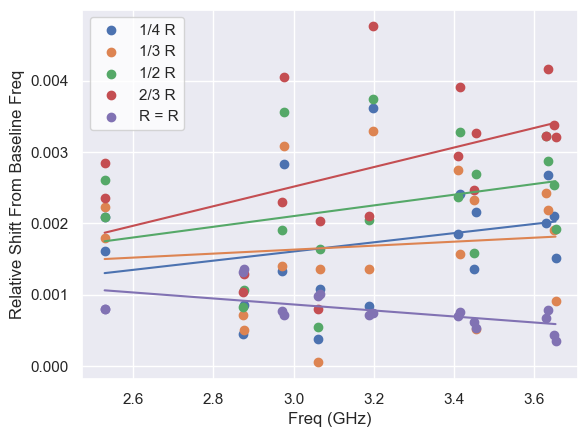

In [253]:
# MAG VERSION

# for quarter R
quarter_R_RelShift_slope, quarter_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts_mag.iloc[1, 1:], 1)
quarter_R_RelShift_y_fit = quarter_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + quarter_R_RelShift_int

# for third R 
third_R_RelShift_slope, third_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts_mag.iloc[2, 1:], 1)
third_R_RelShift_y_fit = third_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + third_R_RelShift_int

# for half R
half_R_RelShift_slope, half_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts_mag.iloc[3, 1:], 1)
half_R_RelShift_y_fit = half_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + half_R_RelShift_int

# for two thirds R
twothirds_R_RelShift_slope, twothirds_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts_mag.iloc[4, 1:], 1)
twothirds_R_RelShift_y_fit = twothirds_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + twothirds_R_RelShift_int

# for full R
full_R_RelShift_slope, full_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts_mag.iloc[5, 1:], 1)
full_R_RelShift_y_fit = full_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + full_R_RelShift_int

# plot all relative shifts (MAG VERSION) 

plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts_mag.iloc[1, 1:], label = f'1/4 R')
plt.plot(resonances_df_full.iloc[0, 1:], quarter_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts_mag.iloc[2, 1:], label = '1/3 R')
plt.plot(resonances_df_full.iloc[0, 1:], third_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts_mag.iloc[3, 1:], label = '1/2 R')
plt.plot(resonances_df_full.iloc[0, 1:], half_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts_mag.iloc[4, 1:], label = '2/3 R')
plt.plot(resonances_df_full.iloc[0, 1:], twothirds_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts_mag.iloc[5, 1:], label = 'R = R')
plt.plot(resonances_df_full.iloc[0, 1:], full_R_RelShift_y_fit)

plt.legend(facecolor='white')
plt.xlabel('Freq (GHz)')
plt.ylabel('Relative Shift From Baseline Freq')

Text(0, 0.5, 'Relative Shift From Baseline Freq')

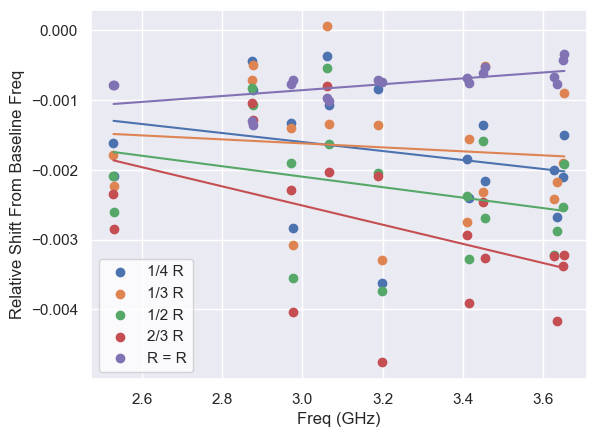

In [269]:
# JUST REGULAR 

# for quarter R
quarter_R_RelShift_slope, quarter_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts.iloc[1, 1:], 1)
quarter_R_RelShift_y_fit = quarter_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + quarter_R_RelShift_int

# for third R 
third_R_RelShift_slope, third_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts.iloc[2, 1:], 1)
third_R_RelShift_y_fit = third_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + third_R_RelShift_int

# for half R
half_R_RelShift_slope, half_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts.iloc[3, 1:], 1)
half_R_RelShift_y_fit = half_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + half_R_RelShift_int

# for two thirds R
twothirds_R_RelShift_slope, twothirds_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts.iloc[4, 1:], 1)
twothirds_R_RelShift_y_fit = twothirds_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + twothirds_R_RelShift_int

# for full R
full_R_RelShift_slope, full_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts.iloc[5, 1:], 1)
full_R_RelShift_y_fit = full_R_RelShift_slope * resonances_df_full.iloc[0, 1:] + full_R_RelShift_int


# plot all relative shifts 

plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts.iloc[1, 1:], label = f'1/4 R')
plt.plot(resonances_df_full.iloc[0, 1:], quarter_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts.iloc[2, 1:], label = '1/3 R')
plt.plot(resonances_df_full.iloc[0, 1:], third_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts.iloc[3, 1:], label = '1/2 R')
plt.plot(resonances_df_full.iloc[0, 1:], half_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts.iloc[4, 1:], label = '2/3 R')
plt.plot(resonances_df_full.iloc[0, 1:], twothirds_R_RelShift_y_fit)


plt.scatter(resonances_df_full.iloc[0, 1:], relative_shifts.iloc[5, 1:], label = 'R = R')
plt.plot(resonances_df_full.iloc[0, 1:], full_R_RelShift_y_fit)

plt.legend(facecolor='white')
plt.xlabel('Freq (GHz)')
plt.ylabel('Relative Shift From Baseline Freq')

In [258]:
relative_shifts_mag

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.250000,0.001617,0.002094,0.000447,0.000859,0.001331,0.002832,0.000379,0.001075,0.000843,0.003618,0.001851,0.002411,0.001364,0.002160,0.002003,0.002672,0.002103,0.001509
2,0.333333,0.001786,0.002229,0.000720,0.000508,0.001401,0.003076,0.000049,0.001353,0.001362,0.003286,0.002753,0.001565,0.002321,0.000521,0.002417,0.002181,0.001901,0.000908
3,0.500000,0.002089,0.002601,0.000825,0.001071,0.001905,0.003554,0.000545,0.001633,0.002041,0.003740,0.002370,0.003282,0.001587,0.002689,0.003217,0.002870,0.002533,0.001920
4,0.666667,0.002349,0.002850,0.001040,0.001294,0.002294,0.004043,0.000796,0.002035,0.002095,0.004758,0.002936,0.003907,0.002468,0.003269,0.003228,0.004164,0.003372,0.003215
5,1.000000,0.000792,0.000794,0.001310,0.001354,0.000776,0.000711,0.000978,0.001015,0.000710,0.000744,0.000694,0.000756,0.000615,0.000533,0.000672,0.000779,0.000430,0.000348


In [265]:
# Drop Radius column
shift_values_only = relative_shifts.drop(columns=['Radius'])

# Find max of each column
min_values = relative_shifts.min()

# Convert to DataFrame
min_df = min_values.to_frame().T  # Transpose to make it a single row


min_df

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.0,-0.002349,-0.00285,-0.00131,-0.001354,-0.002294,-0.004043,-0.000978,-0.002035,-0.002095,-0.004758,-0.002936,-0.003907,-0.002468,-0.003269,-0.003228,-0.004164,-0.003372,-0.003215


Text(0, 0.5, 'Largest absolute frequency shift')

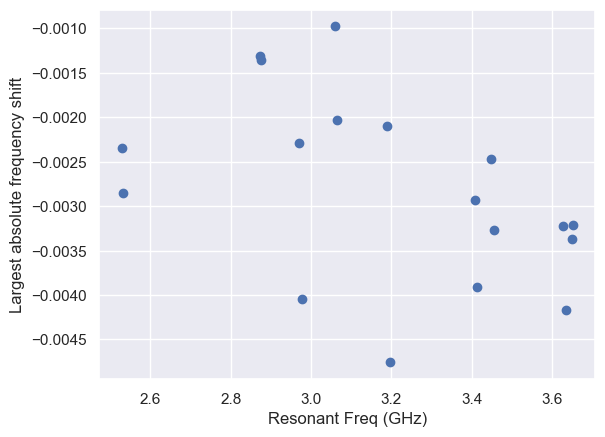

In [268]:
plt.scatter(resonances_df_full.iloc[0, 1:], min_df.iloc[0, 1:])
plt.xlabel('Resonant Freq (GHz)')
plt.ylabel('Largest absolute frequency shift')

In [236]:
np.polyfit?

Signature:       np.polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
Call signature:  np.polyfit(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function polyfit at 0x1061ceb60>
File:            ~/anaconda3/lib/python3.11/site-packages/numpy/lib/polynomial.py
Docstring:      
Least squares polynomial fit.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

Fit a polynomial ``p(x) = p[0] * x**deg + ... + p[deg]`` of degree `deg`
to points `(x, y)`. Returns a vector of coefficients `p` that minimises
the squared error in the order `deg`, `deg-1`, ... `0`.

The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
method is recommended for new code as it is more stable numerically. See
the documentation of the method for more in

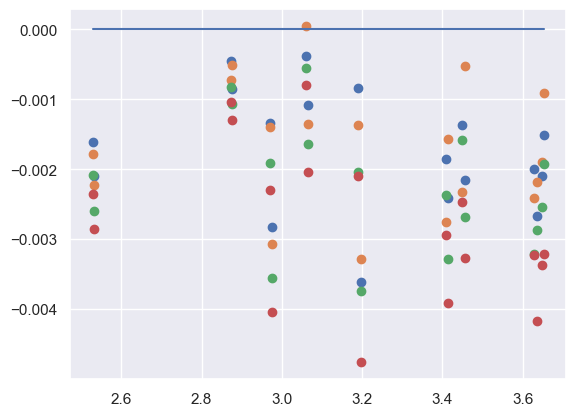

In [ ]:
#plt.plot(resonances_df.iloc[0, 1:], relative_shifts.iloc[0, 1:])
plt.scatter(resonances_df.iloc[0, 1:], relative_shifts.iloc[1, 1:])
plt.scatter(resonances_df.iloc[0, 1:], relative_shifts.iloc[2, 1:])
plt.scatter(resonances_df.iloc[0, 1:], relative_shifts.iloc[3, 1:])
plt.scatter(resonances_df.iloc[0, 1:], relative_shifts.iloc[4, 1:])

In [214]:
relative_shifts.iloc[0, 1:]

TE 2.5 I      0.0
TE 2.5 II     0.0
TM 2.87 I     0.0
TM 2.87 II    0.0
TE 2.97 I     0.0
TE 2.97 II    0.0
TM 3.05 I     0.0
TM 3.05 II    0.0
TE 3.19 I     0.0
TE 3.19 II    0.0
TE 3.41 I     0.0
TE 3.41 II    0.0
TM 3.45 I     0.0
TM 3.45 II    0.0
TE 3.62 I     0.0
TE 3.62 II    0.0
TM 3.64 I     0.0
TM 3.64 II    0.0
Name: 0, dtype: float64

In [ ]:
quarter_R_RelShift_slope, quarter_R_RelShift_int = np.polyfit(resonances_df_full.iloc[0, 1:], 
                                                              relative_shifts)

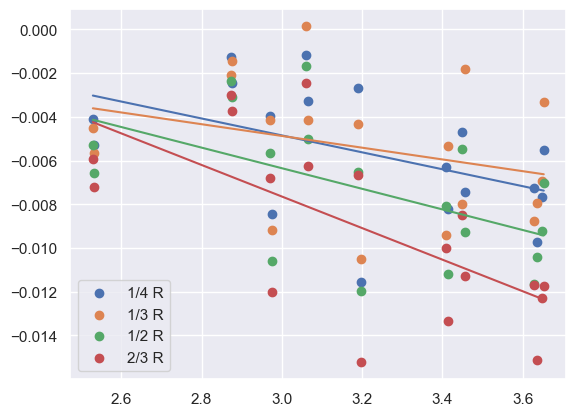

In [132]:
# quarter R deltas
quarter_R_delta_slope, quarter_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                         radius_deltas.iloc[1, 1:], 1)
quarter_R_y_fit = quarter_R_delta_slope * radius_deltas.iloc[0, 1:] + quarter_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[1, 1:], label = '1/4 R')
plt.plot(radius_deltas.iloc[0, 1:], quarter_R_y_fit)

# third R deltas 
third_R_delta_slope, third_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                     radius_deltas.iloc[2, 1:], 1)
third_R_y_fit = third_R_delta_slope * radius_deltas.iloc[0, 1:] + third_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[2, 1:], label = '1/3 R')
plt.plot(radius_deltas.iloc[0, 1:], third_R_y_fit)

# half R deltas 
half_R_delta_slope, half_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                   radius_deltas.iloc[3, 1:], 1)
half_R_y_fit = half_R_delta_slope * radius_deltas.iloc[0, 1:] + half_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[3, 1:], label = '1/2 R')
plt.plot(radius_deltas.iloc[0, 1:], half_R_y_fit)

# two thirds R deltas 
twothirds_R_delta_slope, twothirds_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                             radius_deltas.iloc[4, 1:], 1)
twothirds_R_y_fit = twothirds_R_delta_slope * radius_deltas.iloc[0, 1:] + twothirds_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[4, 1:], label = '2/3 R')
plt.plot(radius_deltas.iloc[0, 1:], twothirds_R_y_fit)

plt.legend()

In [213]:
# VERSION with relative shifts

# quarter R relative shifts
quarter_R_slope, quarter_R_intercept = np.polyfit(relative_shifts.iloc[0, 1:], 
                                                  relative_shifts.iloc[1, 1:], 1)
quarter_R_y_fit = quarter_R_slope * relative_shifts.iloc[0, 1:] + quarter_R_intercept
plt.scatter(relative_shifts.iloc[0, 1:], relative_shifts.iloc[1, 1:], label='1/4 R', color='blue')
plt.plot(relative_shifts.iloc[0, 1:], quarter_R_y_fit, color='blue')

# third R relative shifts
third_R_slope, third_R_intercept = np.polyfit(relative_shifts.iloc[0, 1:], 
                                              relative_shifts.iloc[2, 1:], 1)
third_R_y_fit = third_R_slope * relative_shifts.iloc[0, 1:] + third_R_intercept
plt.scatter(relative_shifts.iloc[0, 1:], relative_shifts.iloc[2, 1:], label='1/3 R', color='green')
plt.plot(relative_shifts.iloc[0, 1:], third_R_y_fit, color='green')

# half R relative shifts
half_R_slope, half_R_intercept = np.polyfit(relative_shifts.iloc[0, 1:], 
                                            relative_shifts.iloc[3, 1:], 1)
half_R_y_fit = half_R_slope * relative_shifts.iloc[0, 1:] + half_R_intercept
plt.scatter(relative_shifts.iloc[0, 1:], relative_shifts.iloc[3, 1:], label='1/2 R', color='orange')
plt.plot(relative_shifts.iloc[0, 1:], half_R_y_fit, color='orange')

# two thirds R relative shifts
twothirds_R_slope, twothirds_R_intercept = np.polyfit(relative_shifts.iloc[0, 1:], 
                                                      relative_shifts.iloc[4, 1:], 1)
twothirds_R_y_fit = twothirds_R_slope * relative_shifts.iloc[0, 1:] + twothirds_R_intercept
plt.scatter(relative_shifts.iloc[0, 1:], relative_shifts.iloc[4, 1:], label='2/3 R', color='red')
plt.plot(relative_shifts.iloc[0, 1:], twothirds_R_y_fit, color='red')

plt.legend(facecolor='white')
plt.xlabel('Baseline freq (GHz)')
plt.ylabel(r'Relative shift: $(f_{r,i} - f_{r,0}) / f_{r,0}$')
plt.title(r'Relative Frequency Shift vs. TE/TM Location')
plt.grid(True)
plt.show()

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

Text(0.5, 1.0, 'Frequency Shift Magnitude, $\\Delta f$  vs. TE/TM Location')

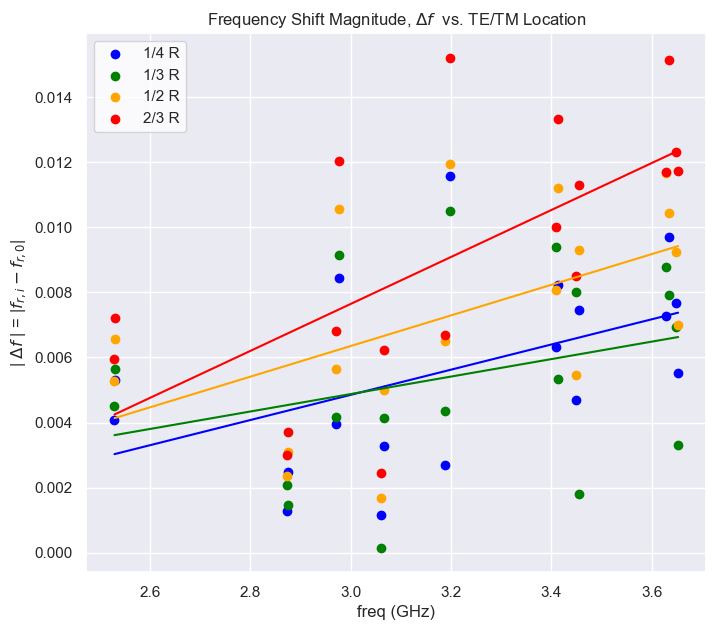

In [133]:
# MAG VERSION
plt.figure(figsize = (8, 7))
# quarter R deltas
quarter_R_delta_slope, quarter_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                         radius_deltas.iloc[1, 1:], 1)
quarter_R_y_fit = quarter_R_delta_slope * radius_deltas.iloc[0, 1:] + quarter_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[1, 1:]), label = '1/4 R', color = 'blue')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(quarter_R_y_fit), color = 'blue')

# third R deltas 
third_R_delta_slope, third_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                     radius_deltas.iloc[2, 1:], 1)
third_R_y_fit = third_R_delta_slope * radius_deltas.iloc[0, 1:] + third_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[2, 1:]), label = '1/3 R', color = 'green')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(third_R_y_fit), color = 'green')

# half R deltas 
half_R_delta_slope, half_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                   radius_deltas.iloc[3, 1:], 1)
half_R_y_fit = half_R_delta_slope * radius_deltas.iloc[0, 1:] + half_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[3, 1:]), label = '1/2 R', color = 'orange')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(half_R_y_fit), color = 'orange')

# two thirds R deltas 
twothirds_R_delta_slope, twothirds_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                             radius_deltas.iloc[4, 1:], 1)
twothirds_R_y_fit = twothirds_R_delta_slope * radius_deltas.iloc[0, 1:] + twothirds_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[4, 1:]), label = '2/3 R', color = 'red')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(twothirds_R_y_fit), color = 'red')

plt.legend(facecolor='white')
plt.xlabel('freq (GHz)')
plt.ylabel(r'| $\Delta f$ | = |$f_{r,i} - f_{r,0}$|')
plt.title(f'Frequency Shift Magnitude, $\Delta f$  vs. TE/TM Location')


Text(0, 0.5, '$\\Delta f$')

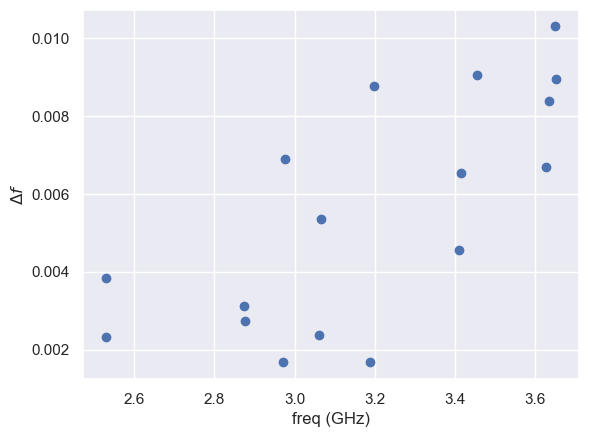

In [309]:
plt.scatter(deltas.iloc[0], np.abs(deltas.iloc[1]))
plt.xlabel('freq (GHz)')
plt.ylabel(f'$\Delta f$')

Text(0.5, 1.0, 'Total Frequency Shift, $\\Delta f$  vs. TE/TM Location')

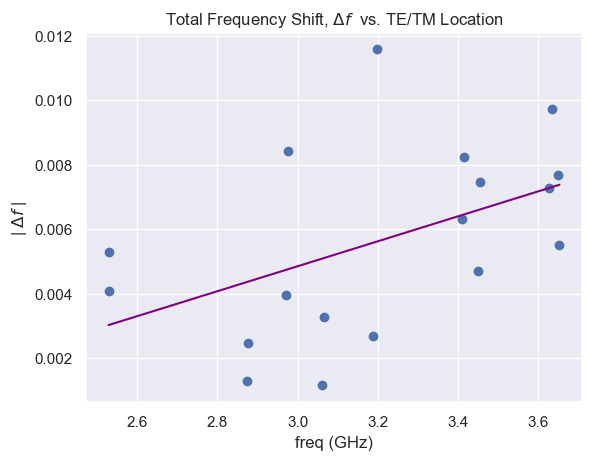

In [140]:
slope, int = np.polyfit(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[1, 1:]), 1)

y_fit = slope * radius_deltas.iloc[0, 1:] + int

plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[1, 1:]))
plt.xlabel('freq (GHz)')
plt.ylabel(f'| $\Delta f$ |')
plt.plot(radius_deltas.iloc[0, 1:], y_fit, color='purple')
plt.title(f'Total Frequency Shift, $\Delta f$  vs. TE/TM Location')

In [142]:
# getting max Q for each zotefoam radius 
alumina_peaks_Qmax = alumina_peaks[alumina_peaks['Quality factor (1)']==max(alumina_peaks['Quality factor (1)'])]
quarter_R_peaks_Qmax = quarter_R_Qpeaks[quarter_R_Qpeaks['Quality factor (1)']==max(quarter_R_Qpeaks['Quality factor (1)'])]
third_R_peaks_Qmax = third_R_Qpeaks[third_R_Qpeaks['Quality factor (1)']==max(third_R_Qpeaks['Quality factor (1)'])]
half_R_peaks_Qmax = half_R_Qpeaks[half_R_Qpeaks['Quality factor (1)']==max(half_R_Qpeaks['Quality factor (1)'])]
twothirds_R_peaks_Qmax = twothirds_R_Qpeaks[twothirds_R_Qpeaks['Quality factor (1)']==max(twothirds_R_Qpeaks['Quality factor (1)'])]
full_R_peaks_Qmax = full_R_Qpeaks[full_R_Qpeaks['Quality factor (1)']==max(full_R_Qpeaks['Quality factor (1)'])]

# getting top 5 Q for each zotefoam radius
alumina_peaks_highQ = alumina_peaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
quarter_peaks_highQ = quarter_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
third_peaks_highQ = third_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
half_peaks_highQ = half_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
twothirds_peaks_highQ = twothirds_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
full_peaks_highQ = full_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]


In [143]:
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))
print(np.average(quarter_peaks_highQ['Frequency (GHz)']))
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))

3.1843272725817346
3.248701976635826
3.1843272725817346
3.1843272725817346
3.1843272725817346


In [144]:
top_Qs_peaks = {'no zotefoam': alumina_peaks_highQ, 
                'quarter R': quarter_peaks_highQ, 
                'third R': third_peaks_highQ, 
                'half R': half_peaks_highQ, 
                'two thirds R': twothirds_peaks_highQ, 
                'full R': full_peaks_highQ}

top_Qs_peaks_list = [alumina_peaks_highQ, 
                     quarter_peaks_highQ, 
                     third_peaks_highQ, 
                     half_peaks_highQ, 
                     twothirds_peaks_highQ, 
                     full_peaks_highQ]

In [145]:
for i in range(len(top_Qs_peaks_list)):
    print(np.average(top_Qs_peaks_list[i]['Quality factor (1)']))

for i in range(len(top_Qs_peaks_list)):
    print(np.average(top_Qs_peaks_list[i]['Frequency (GHz)']))    

21819.65044081906
63249.84823199287
98926.3220578572
221406.10971310324
174399.10145701465
22041.299676516486
3.1843272725817346
3.248701976635826
3.1427726320515452
3.227662276651747
3.3560981680811706
3.18170436803944


In [146]:
# plt.figure()

# plt.plot(radius_column_relative, (top_Qs_peaks_list[i]['Frequency (GHz)'][j] for i in range(len(top_Qs_peaks_list)) and j in range(3)))

In [147]:
top_Qs_peaks_list[0]

,% search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,3.000000e+09,3.065609+0.000058j,3.065609,26220.346692
1,3.500000e+09,3.409475+0.000066j,3.409475,25841.029108
2,3.000000e+09,3.060040+0.000061j,3.060040,24931.664736
3,3.000000e+09,3.188710+0.000091j,3.188710,17433.217155
4,3.000000e+09,3.197803+0.000109j,3.197803,14671.994512


In [148]:
radius_column_x_5 = [[0,0,0,0,0], [0.25,0.25,0.25,0.25,0.25,], 
                     [0.3333333333333333,0.3333333333333333,0.3333333333333333,0.3333333333333333,0.3333333333333333], 
                     [0.5,0.5,0.5,0.5,0.5,], [0.6666666666666666,0.6666666666666666,0.6666666666666666,0.6666666666666666,0.6666666666666666], 
                     [1,1,1,1,1]]

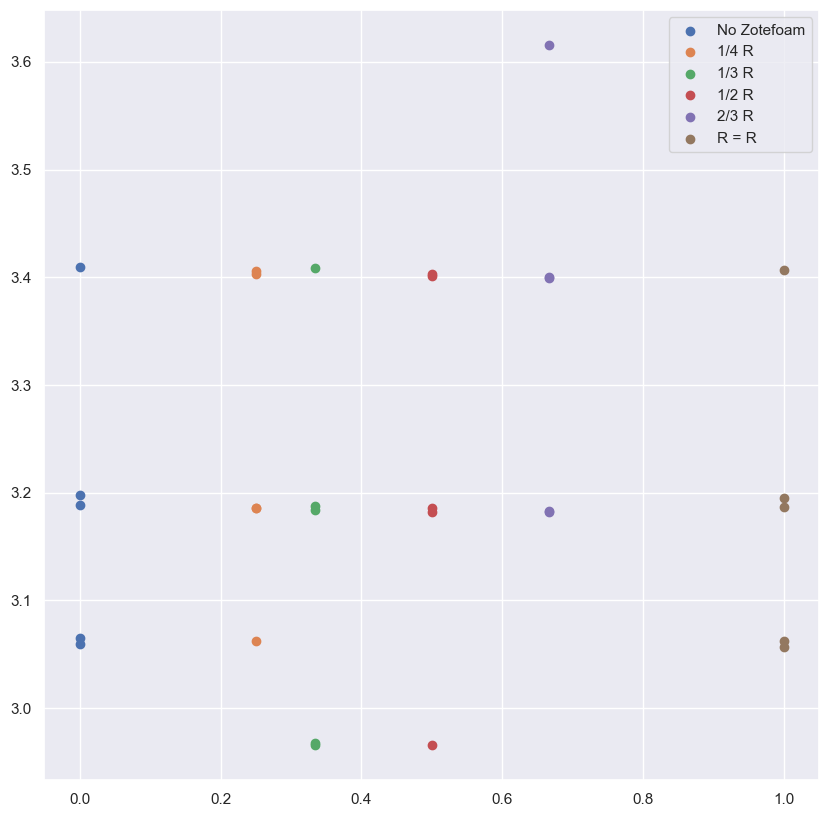

In [149]:
plt.figure(figsize=(10,10))
plt.scatter(radius_column_x_5[0], top_Qs_peaks_list[0]['Frequency (GHz)'], label = 'No Zotefoam')
plt.scatter(radius_column_x_5[1], top_Qs_peaks_list[1]['Frequency (GHz)'], label = '1/4 R')
plt.scatter(radius_column_x_5[2], top_Qs_peaks_list[2]['Frequency (GHz)'], label = '1/3 R')
plt.scatter(radius_column_x_5[3], top_Qs_peaks_list[3]['Frequency (GHz)'], label = '1/2 R')
plt.scatter(radius_column_x_5[4], top_Qs_peaks_list[4]['Frequency (GHz)'], label = '2/3 R')
plt.scatter(radius_column_x_5[5], top_Qs_peaks_list[5]['Frequency (GHz)'], label = 'R = R')
plt.legend()

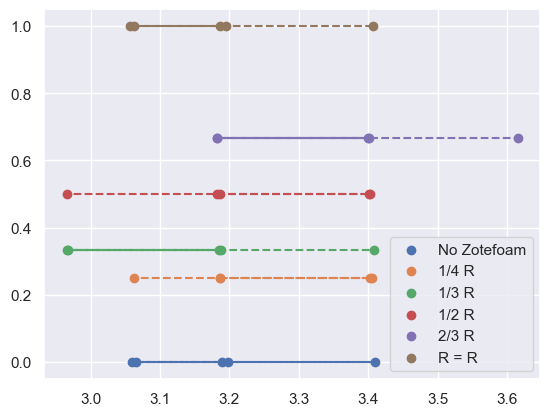

In [150]:
plt.scatter(top_Qs_peaks_list[0]['Frequency (GHz)'], radius_column_x_5[0], label = 'No Zotefoam')
plt.plot(top_Qs_peaks_list[0]['Frequency (GHz)'], radius_column_x_5[0], ls='dashed')

plt.scatter(top_Qs_peaks_list[1]['Frequency (GHz)'], radius_column_x_5[1], label = '1/4 R')
plt.plot(top_Qs_peaks_list[1]['Frequency (GHz)'], radius_column_x_5[1], ls='dashed')

plt.scatter(top_Qs_peaks_list[2]['Frequency (GHz)'], radius_column_x_5[2], label = '1/3 R')
plt.plot(top_Qs_peaks_list[2]['Frequency (GHz)'], radius_column_x_5[2], ls='dashed')

plt.scatter(top_Qs_peaks_list[3]['Frequency (GHz)'], radius_column_x_5[3], label = '1/2 R')
plt.plot(top_Qs_peaks_list[3]['Frequency (GHz)'], radius_column_x_5[3], ls='dashed')

plt.scatter(top_Qs_peaks_list[4]['Frequency (GHz)'], radius_column_x_5[4], label = '2/3 R')
plt.plot(top_Qs_peaks_list[4]['Frequency (GHz)'], radius_column_x_5[4], ls='dashed')

plt.scatter(top_Qs_peaks_list[5]['Frequency (GHz)'], radius_column_x_5[5], label = 'R = R')
plt.plot(top_Qs_peaks_list[5]['Frequency (GHz)'], radius_column_x_5[5], ls='dashed')
plt.legend()

#### ^ Zotefoam bringing out TM mode?? 

In [151]:
alumina_peaks_Qmax['Frequency (GHz)'].iloc[0]

3.0656085813880583

In [437]:
radius_column_wfull = [0, 0.25, 0.3333333333333333, 0.5, 0.6666666666666666, 1]

In [152]:
Q_maxes_list = np.array([alumina_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                quarter_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                third_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                half_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                twothirds_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                full_R_peaks_Qmax['Frequency (GHz)'].iloc[0]])

Q_maxes_list

array([3.06560858, 3.18623358, 3.1872937 , 3.18220115, 3.40066806,
       3.40710801])

In [154]:
Q_maxes = pd.DataFrame([radius_column_relative, Q_maxes_list])

In [155]:
Q_maxes

,0,1,2,3,4,5
0,0.000000,0.250000,0.333333,0.500000,0.666667,1.000000
1,3.065609,3.186234,3.187294,3.182201,3.400668,3.407108


Text(0.5, 1.0, 'Freq Location of Lowest Loss')

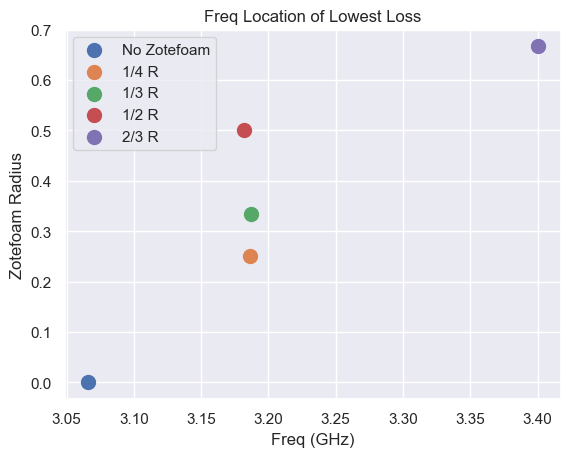

In [159]:
plt.scatter(Q_maxes.iloc[1,0], Q_maxes.iloc[0,0], label = 'No Zotefoam', s = 100)

plt.scatter(Q_maxes.iloc[1,1], Q_maxes.iloc[0,1], label = '1/4 R', s = 100)

plt.scatter(Q_maxes.iloc[1,2], Q_maxes.iloc[0,2], label = '1/3 R', s = 100)

plt.scatter(Q_maxes.iloc[1,3], Q_maxes.iloc[0,3], label = '1/2 R', s = 100)

plt.scatter(Q_maxes.iloc[1,4], Q_maxes.iloc[0,4], label = '2/3 R', s = 100)

plt.legend()
# plt.xlim(2.9, 3.3)
plt.xlabel('Freq (GHz)')
plt.ylabel('Zotefoam Radius')
plt.title('Freq Location of Lowest Loss')

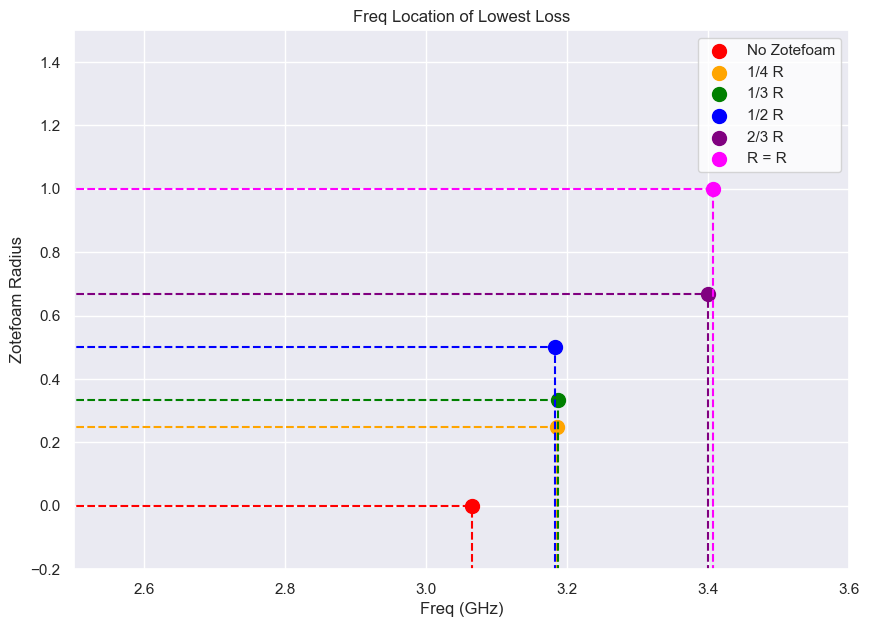

In [160]:
plt.figure(figsize = (10, 7))


plt.scatter(Q_maxes.iloc[1,0], Q_maxes.iloc[0,0], label='No Zotefoam', s=100, color = 'red')
plt.vlines(Q_maxes.iloc[1,0], ymin=-1, ymax=Q_maxes.iloc[0,0], linestyle='dashed', color = 'red')
plt.hlines(Q_maxes.iloc[0,0], xmin=0, xmax=Q_maxes.iloc[1,0], linestyle='dashed', color='red')

plt.scatter(Q_maxes.iloc[1,1], Q_maxes.iloc[0,1], label='1/4 R', s=100, color = 'orange')
plt.vlines(Q_maxes.iloc[1,1], ymin=-1, ymax=Q_maxes.iloc[0,1], linestyle='dashed', color='orange')
plt.hlines(Q_maxes.iloc[0,1], xmin=0, xmax=Q_maxes.iloc[1,1], linestyle='dashed', color='orange')

plt.scatter(Q_maxes.iloc[1,2], Q_maxes.iloc[0,2], label='1/3 R', s=100, color = 'green')
plt.vlines(Q_maxes.iloc[1,2], ymin=-1, ymax=Q_maxes.iloc[0,2], linestyle='dashed', color='green')
plt.hlines(Q_maxes.iloc[0,2], xmin=0, xmax=Q_maxes.iloc[1,2], linestyle='dashed', color='green')

plt.scatter(Q_maxes.iloc[1,3], Q_maxes.iloc[0,3], label='1/2 R', s=100, color = 'blue')
plt.vlines(Q_maxes.iloc[1,3], ymin=-1, ymax=Q_maxes.iloc[0,3], linestyle='dashed', color='blue')
plt.hlines(Q_maxes.iloc[0,3], xmin=0, xmax=Q_maxes.iloc[1,3], linestyle='dashed', color='blue')

plt.scatter(Q_maxes.iloc[1,4], Q_maxes.iloc[0,4], label='2/3 R', s=100, color = 'purple')
plt.vlines(Q_maxes.iloc[1,4], ymin=-1, ymax=Q_maxes.iloc[0,4], linestyle='dashed', color='purple')
plt.hlines(Q_maxes.iloc[0,4], xmin=0, xmax=Q_maxes.iloc[1,4], linestyle='dashed', color='purple')

plt.scatter(Q_maxes.iloc[1,5], Q_maxes.iloc[0,5], label='R = R', s=100, color = 'magenta')
plt.vlines(Q_maxes.iloc[1,5], ymin=-1, ymax=Q_maxes.iloc[0,5], linestyle='dashed', color='magenta')
plt.hlines(Q_maxes.iloc[0,5], xmin=0, xmax=Q_maxes.iloc[1,5], linestyle='dashed', color='magenta')



plt.legend(facecolor='white')
plt.xlim(2.5, 3.6)
plt.ylim(-0.2, 1.5)
plt.xlabel('Freq (GHz)')
plt.ylabel('Zotefoam Radius')
plt.title('Freq Location of Lowest Loss')
plt.show()

In [161]:
print(np.average(alumina_peaks['Quality factor (1)']))
print(np.average(quarter_R_Qpeaks['Quality factor (1)']))
print(np.average(third_R_Qpeaks['Quality factor (1)']))
print(np.average(half_R_Qpeaks['Quality factor (1)']))
print(np.average(twothirds_R_Qpeaks['Quality factor (1)']))
print(np.average(full_R_Qpeaks['Quality factor (1)']))

11108.729350604384
30600.316599740272
46330.63064762007
93261.70248088102
72651.54625217809
11347.973803042913


In [165]:
alumina_peaks

,% search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,2.500000e+09,2.529201+0.000116j,2.529201,10886.747660
1,2.500000e+09,2.530838+0.000115j,2.530838,11031.027270
2,3.000000e+09,2.873249+0.000147j,2.873249,9761.626470
3,3.000000e+09,2.875583+0.000160j,2.875583,9012.052373
4,3.000000e+09,2.970204+0.000361j,2.970204,4119.369403
5,3.000000e+09,2.976651+0.000194j,2.976651,7678.571204
6,3.000000e+09,3.060040+0.000061j,3.060040,24931.664736
7,3.000000e+09,3.065609+0.000058j,3.065609,26220.346692
8,3.000000e+09,3.188710+0.000091j,3.188710,17433.217155
9,3.000000e+09,3.197803+0.000109j,3.197803,14671.994512


In [166]:
Q_peak_averages = np.array([np.average(alumina_peaks['Quality factor (1)']), 
                       np.average(quarter_R_Qpeaks['Quality factor (1)']), 
                       np.average(third_R_Qpeaks['Quality factor (1)']), 
                       np.average(half_R_Qpeaks['Quality factor (1)']), 
                       np.average(twothirds_R_Qpeaks['Quality factor (1)']), 
                       np.average(full_R_Qpeaks['Quality factor (1)'])])

Q_averages = np.array([np.average(just_alumina['Quality factor (1)']), 
                       np.average(quarter_R['Quality factor (1)']), 
                       np.average(third_R['Quality factor (1)']), 
                       np.average(half_R['Quality factor (1)']), 
                       np.average(twothirds_R['Quality factor (1)']), 
                       np.average(full_R['Quality factor (1)'])])

full_R_array = np.array([0, 0.25, 0.3333333333333333, 0.5, 0.6666666666666666, 1])



Text(0, 0.5, 'Q')

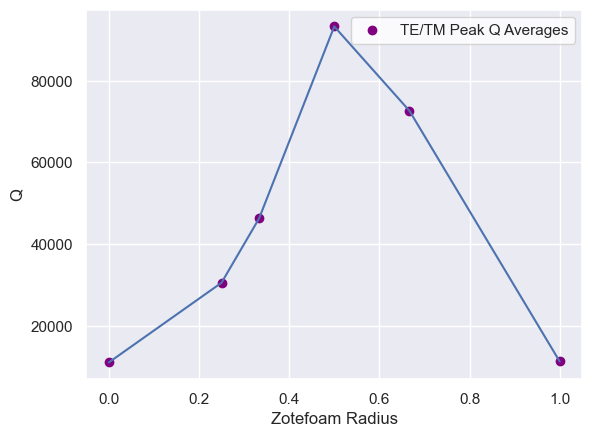

In [167]:
plt.plot(full_R_array, Q_peak_averages)
plt.scatter(full_R_array, Q_peak_averages, label = 'TE/TM Peak Q Averages', color='purple')
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Radius')
plt.ylabel('Q')

Text(0, 0.5, 'Q')

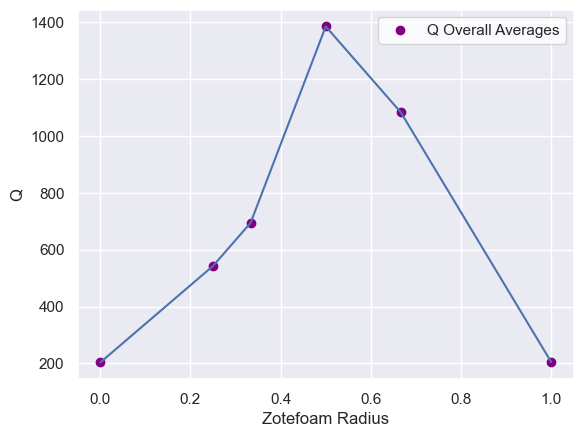

In [168]:
plt.plot(full_R_array, Q_averages)
plt.scatter(full_R_array, Q_averages, label = 'Q Overall Averages', color='purple')
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Radius')
plt.ylabel('Q')

In [169]:
# plt.plot(alumina_peaks_Qmax['Frequency (GHz)'], 
#          alumina_peaks_Qmax['Quality factor (1)'], 
#          label = 'No Zotefoam')

# plt.plot(quarter_R_peaks_Qmax['Frequency (GHz)'], 
#          quarter_R_peaks_Qmax['Quality factor (1)'], 
#          label = '1/4 R')

# plt.plot(third_R_peaks_Qmax['Frequency (GHz)'], 
#          third_R_peaks_Qmax['Quality factor (1)'], 
#          label = '1/3 R')

# plt.plot(half_R_peaks_Qmax['Frequency (GHz)'], 
#          half_R_peaks_Qmax['Quality factor (1)'], 
#          label = '1/2 R')

# plt.plot(twothirds_R_peaks_Qmax['Frequency (GHz)'], 
#          twothirds_R_peaks_Qmax['Quality factor (1)'], 
#          label = '2/3 R')

In [170]:
max_Qs = [max(alumina_peaks['Quality factor (1)']), 
          max(quarter_R_Qpeaks['Quality factor (1)']), 
          max(third_R_Qpeaks['Quality factor (1)']), 
          max(half_R_Qpeaks['Quality factor (1)']), 
          max(twothirds_R_Qpeaks['Quality factor (1)'])]

max_Qs_full = [max(alumina_peaks['Quality factor (1)']), 
          max(quarter_R_Qpeaks['Quality factor (1)']), 
          max(third_R_Qpeaks['Quality factor (1)']), 
          max(half_R_Qpeaks['Quality factor (1)']), 
          max(twothirds_R_Qpeaks['Quality factor (1)']), 
          max(full_R_Qpeaks['Quality factor (1)'])]

In [173]:
q_fac_radius = pd.DataFrame([radius_column_relative_short, max_Qs])
q_fac_radius

,0,1,2,3,4
0,0.000000,0.250000,0.333333,0.500000,0.666667
1,26220.346692,95544.161431,163102.156912,363204.493259,224935.452856


In [176]:
q_fac_radius_full = pd.DataFrame([radius_column_relative, max_Qs_full])
q_fac_radius_full

,0,1,2,3,4,5
0,0.000000,0.250000,0.333333,0.500000,0.666667,1.000000
1,26220.346692,95544.161431,163102.156912,363204.493259,224935.452856,28870.221017


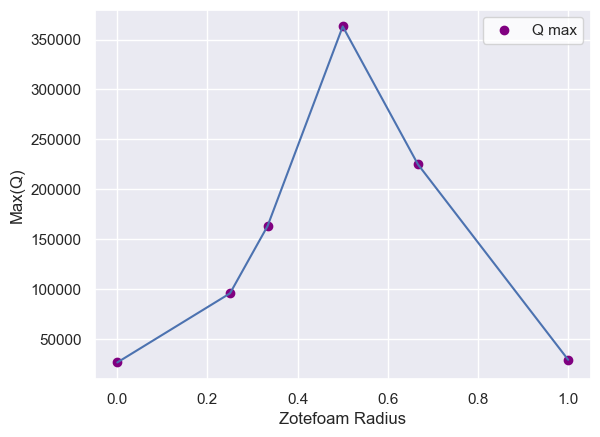

In [178]:
plt.scatter(q_fac_radius_full.iloc[0], q_fac_radius_full.iloc[1], label = 'Q max', color='purple')
plt.plot(q_fac_radius_full.iloc[0], q_fac_radius_full.iloc[1])
plt.xlabel('Zotefoam Radius')
plt.ylabel('Max(Q)')
plt.legend(facecolor='white')

## Plotting TE/TM Frequency location vs. Radius

In [179]:
resonances_df

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45 I,TM 3.45 II,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.449444,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.525111,2.525538,2.871965,2.873113,2.966250,2.968221,3.058881,3.062315,3.186023,3.186234,3.403163,3.405776,3.444741,3.447684,3.620184,3.624657,3.641323,3.646923
2,0.333333,2.524683,2.525197,2.871180,2.874121,2.966043,2.967495,3.060191,3.061462,3.184366,3.187294,3.400090,3.408665,3.441439,3.453346,3.618681,3.626443,3.642059,3.649120
3,0.500000,2.523918,2.524255,2.870879,2.872502,2.964545,2.966071,3.058371,3.060603,3.182201,3.185843,3.401393,3.402803,3.443970,3.445856,3.615781,3.623937,3.639753,3.645424
4,0.666667,2.523259,2.523624,2.870259,2.871861,2.963390,2.964617,3.057603,3.059370,3.182031,3.182589,3.399465,3.400668,3.440930,3.443851,3.615739,3.619234,3.636692,3.640691


In [180]:
resonances_df.columns

Index(['Radius', 'TE 2.5 I', 'TE 2.5 II', 'TM 2.87 I', 'TM 2.87 II',
       'TE 2.97 I', 'TE 2.97 II', 'TM 3.05 I', 'TM 3.05 II', 'TE 3.19 I',
       'TE 3.19 II', 'TE 3.41 I', 'TE 3.41 II', 'TM 3.45 I', 'TM 3.45 II',
       'TE 3.62 I', 'TE 3.62 II', 'TM 3.64 I', 'TM 3.64 II'],
      dtype='object')

In [336]:
# plt.figure()
# # plt.plot(resonances_df['Radius'], resonances_df[0], label = '2.5 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[1], label = '2.5 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[2], label = '2.87 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[3], label = '2.87 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[4], label = '2.97 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[5], label = '2.97 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[6], label = '3.06 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[7], label = '3.06 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[8], label = '3.18 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[9], label = '3.18 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[10], label = '3.4 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[11], label = '3.4 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[12], label = '3.44 GHz')
# plt.plot(resonances_df['Radius'], resonances_df['TE 3.62 I'], label = '3.62 GHz 1 (TE)')
# plt.plot(resonances_df['Radius'], resonances_df['TE 3.62 II'], label = '3.62 GHz 2 (TE)')
# plt.plot(resonances_df['Radius'], resonances_df['TM 3.64 I'], label = '3.64 GHz 1 (TM)')
# plt.plot(resonances_df['Radius'], resonances_df['TM 3.64 II'], label = '3.64 GHz 2 (TM)')
# plt.xlabel('Zotefoam Contact Radius')
# plt.ylabel('Frequency Location of TE/TM mode')
# plt.title('Resonant Mode Location vs. Zotefoam Radius')
# plt.legend()




Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

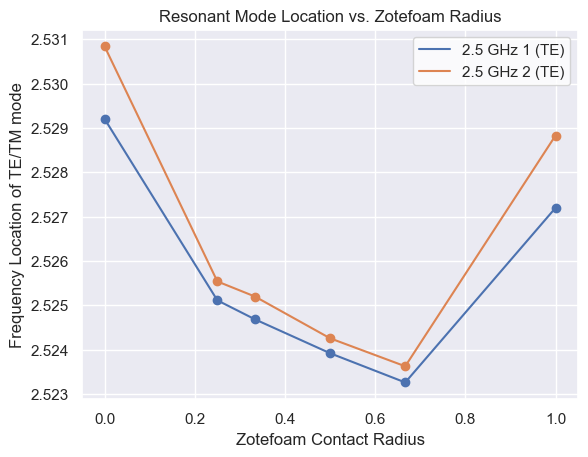

In [270]:
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 2.5 I'], label = '2.5 GHz 1 (TE)')
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 2.5 II'], label = '2.5 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 2.5 I'])
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 2.5 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

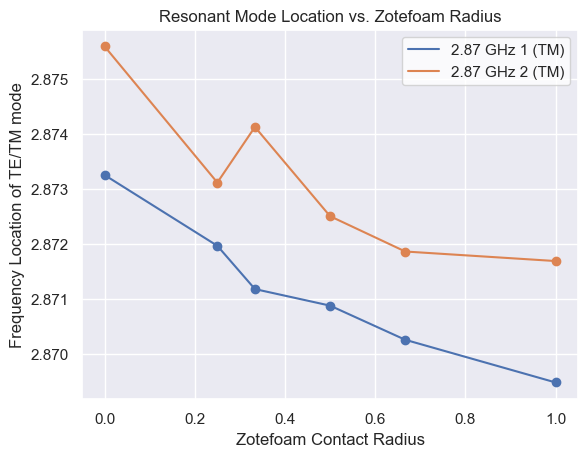

In [271]:
plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 2.87 I'], label = '2.87 GHz 1 (TM)')
plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 2.87 II'], label = '2.87 GHz 2 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 2.87 I'])
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 2.87 II'])

plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

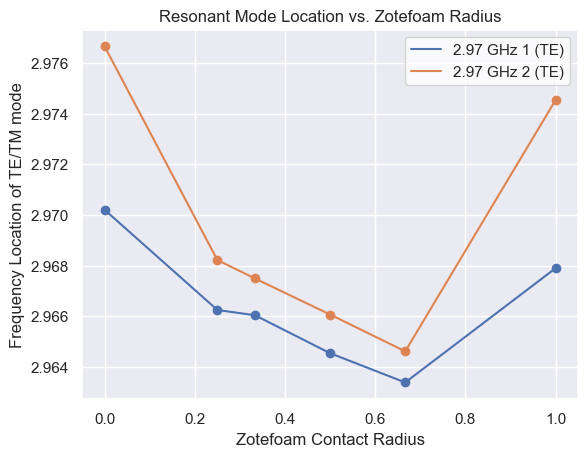

In [272]:

plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 2.97 I'], label = '2.97 GHz 1 (TE)')
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 2.97 II'], label = '2.97 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 2.97 I'])
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 2.97 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

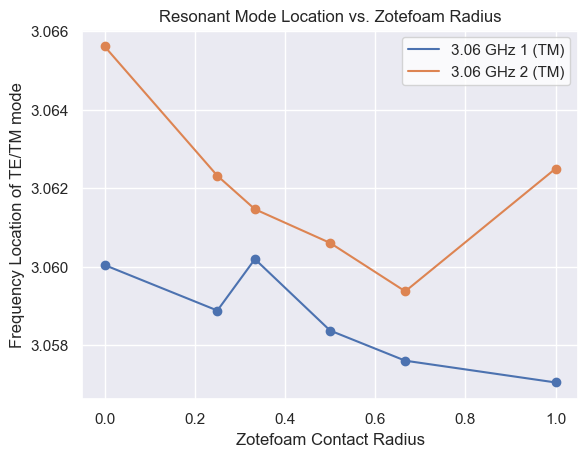

In [273]:
plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.05 I'], label = '3.06 GHz 1 (TM)')
plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.05 II'], label = '3.06 GHz 2 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.05 I'])
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.05 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

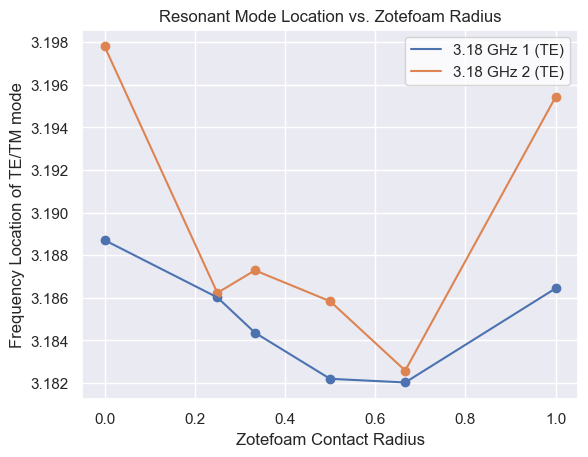

In [274]:
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.19 I'], label = '3.18 GHz 1 (TE)')
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.19 II'], label = '3.18 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.19 I'])
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.19 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

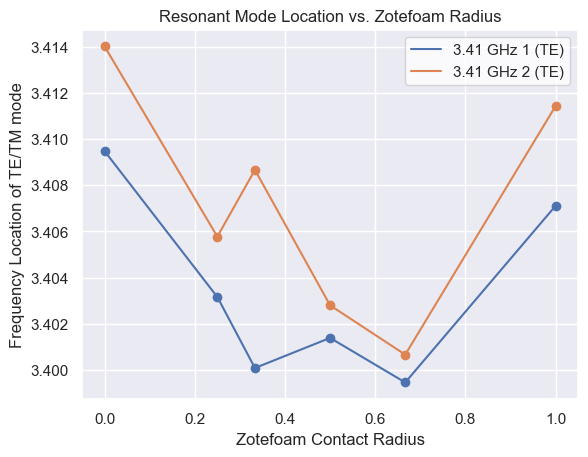

In [192]:
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.41 I'], label = '3.41 GHz 1 (TE)')
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.41 II'], label = '3.41 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.41 I'])
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.41 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

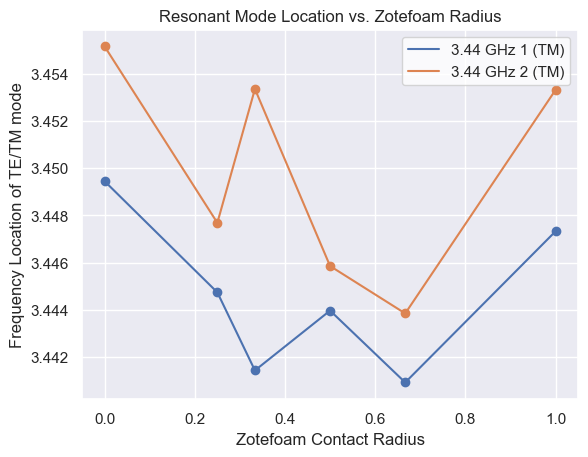

In [193]:
plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.45 I'], label = '3.44 GHz 1 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.45 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.45 II'], label = '3.44 GHz 2 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.45 II'])

plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

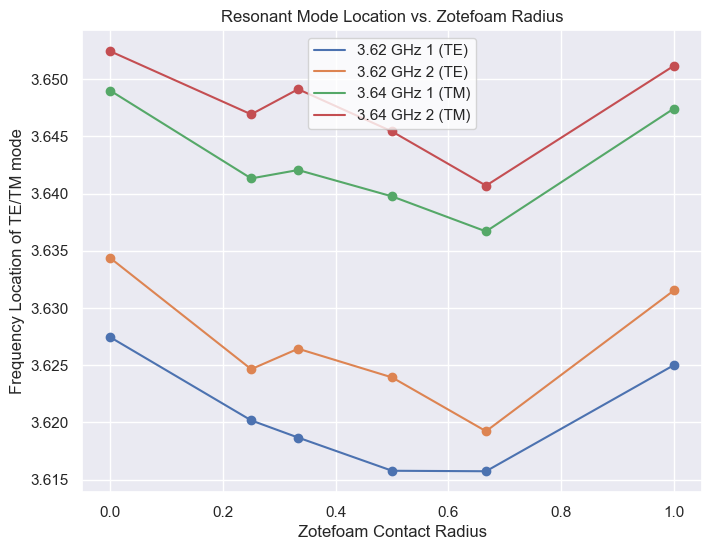

In [194]:
plt.figure(figsize = (8,6))
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.62 I'], label = '3.62 GHz 1 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.62 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.62 II'], label = '3.62 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.62 II'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.64 I'], label = '3.64 GHz 1 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.64 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.64 II'], label = '3.64 GHz 2 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.64 II'])


plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')
plt.legend(facecolor='white')

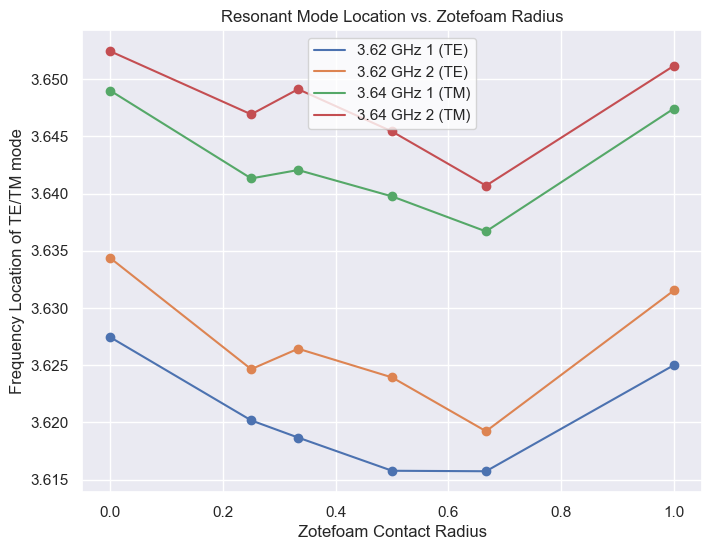

In [195]:
plt.figure(figsize = (8,6))
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.62 I'], label = '3.62 GHz 1 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.62 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.62 II'], label = '3.62 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.62 II'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.64 I'], label = '3.64 GHz 1 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.64 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.64 II'], label = '3.64 GHz 2 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.64 II'])


plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')
plt.legend(facecolor='white')

## IGNORE REST 

Plan: get data into a situation where I can plot radius vs. frequency for one peak... or for multiple

(2.5, 4.0)

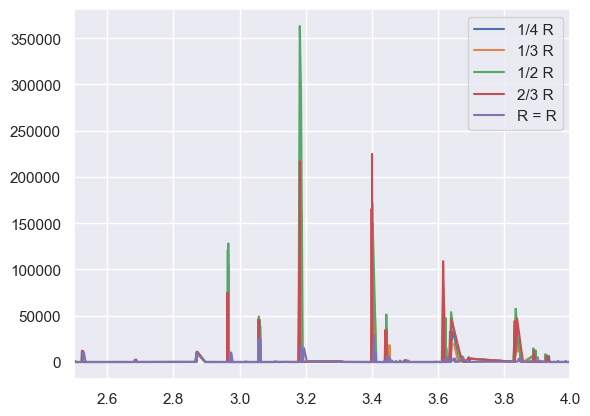

In [203]:
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(2.5, 4.0)

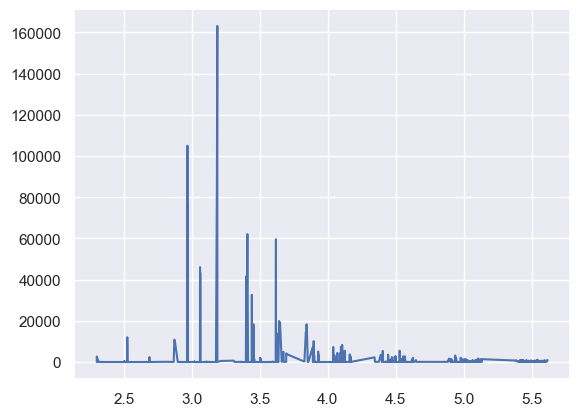

In [204]:
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = 'R = R')

In [206]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=quarter_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 50000, 
                label = str(quarter_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R', lw=2, color = 'red')
plt.legend(facecolor = 'white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/4 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

NameError: name 'quarter_R_peaks' is not defined

<Figure size 1200x800 with 0 Axes>

In [209]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=third_R_Qpeaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(third_R_Qpeaks['Frequency (GHz)'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/3 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/3 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

KeyError: 'freqs'

<Figure size 1200x800 with 0 Axes>

Text(0, 0.5, 'Q Factor')

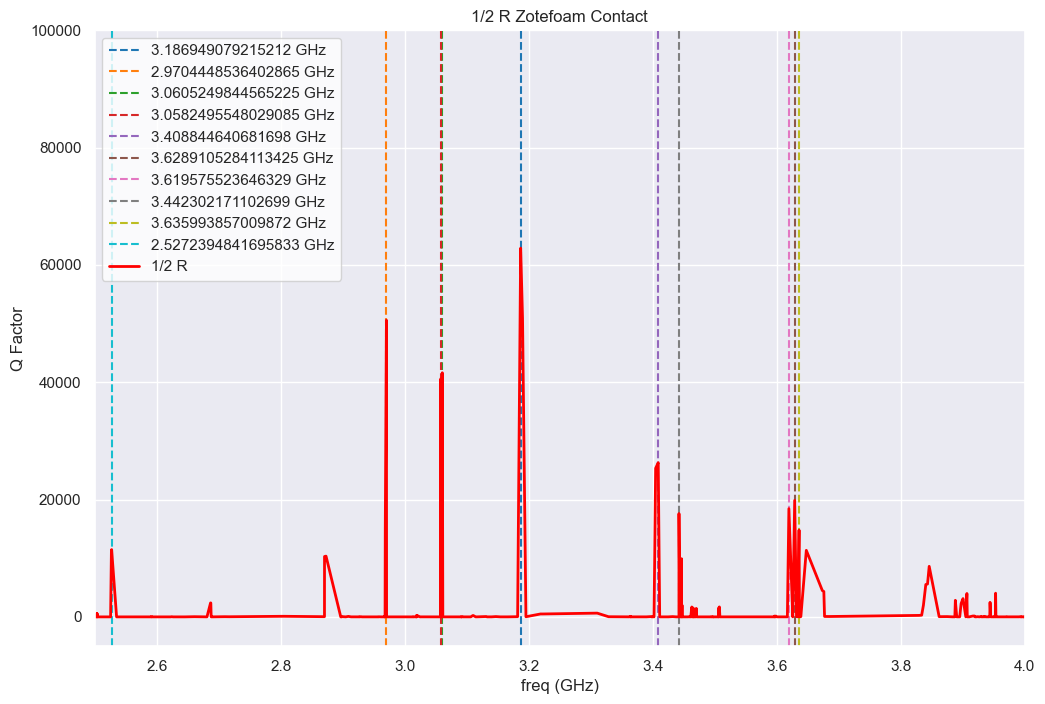

In [85]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=half_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(half_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(half_R_reduced['Frequency (GHz)'], half_R_reduced['Quality factor (1)'], label = '1/2 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/2 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

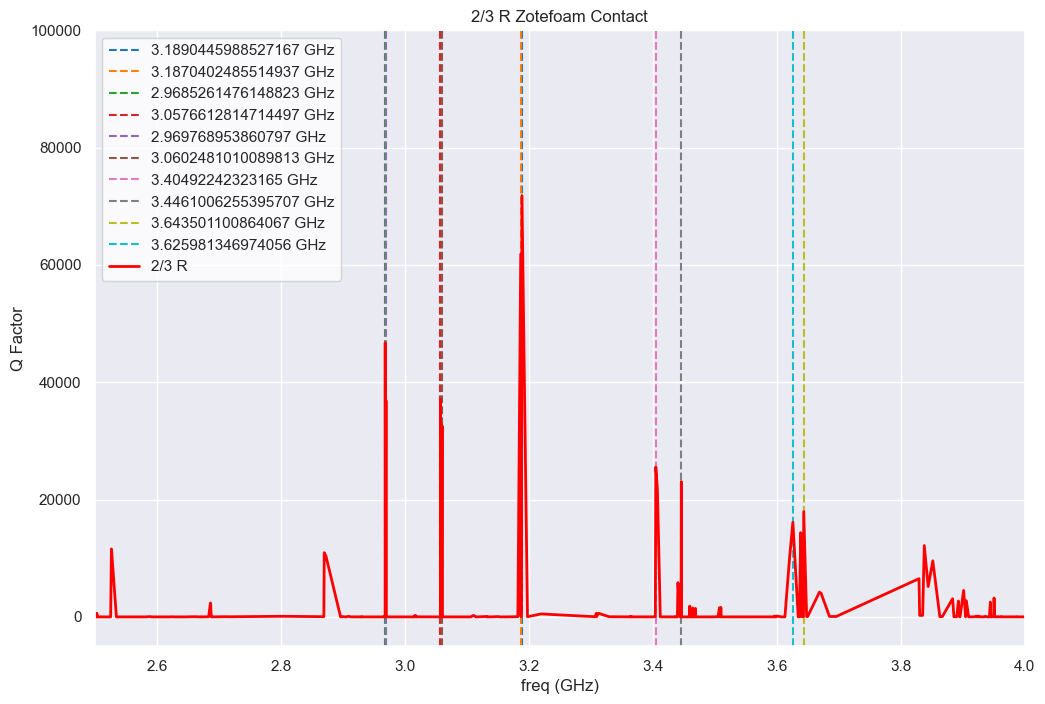

In [86]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=twothirds_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(twothirds_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(twothirds_R_reduced['Frequency (GHz)'], twothirds_R_reduced['Quality factor (1)'], label = '2/3 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('2/3 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

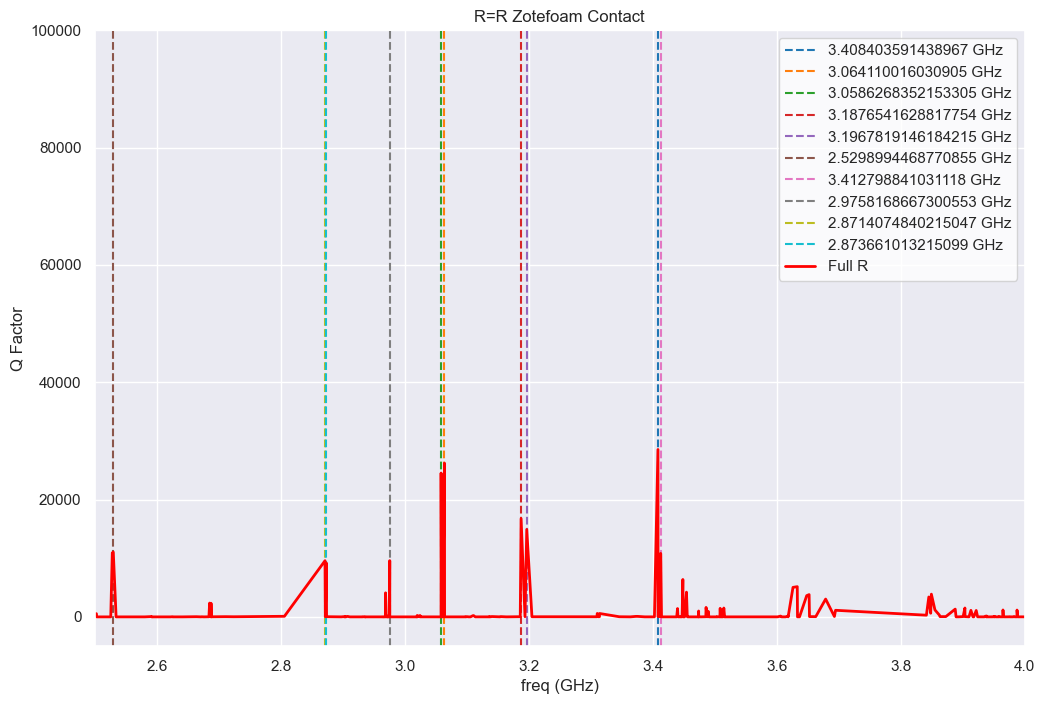

In [87]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=full_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(full_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(full_R_reduced['Frequency (GHz)'], full_R_reduced['Quality factor (1)'], label = 'Full R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('R=R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

(3.175, 3.215)

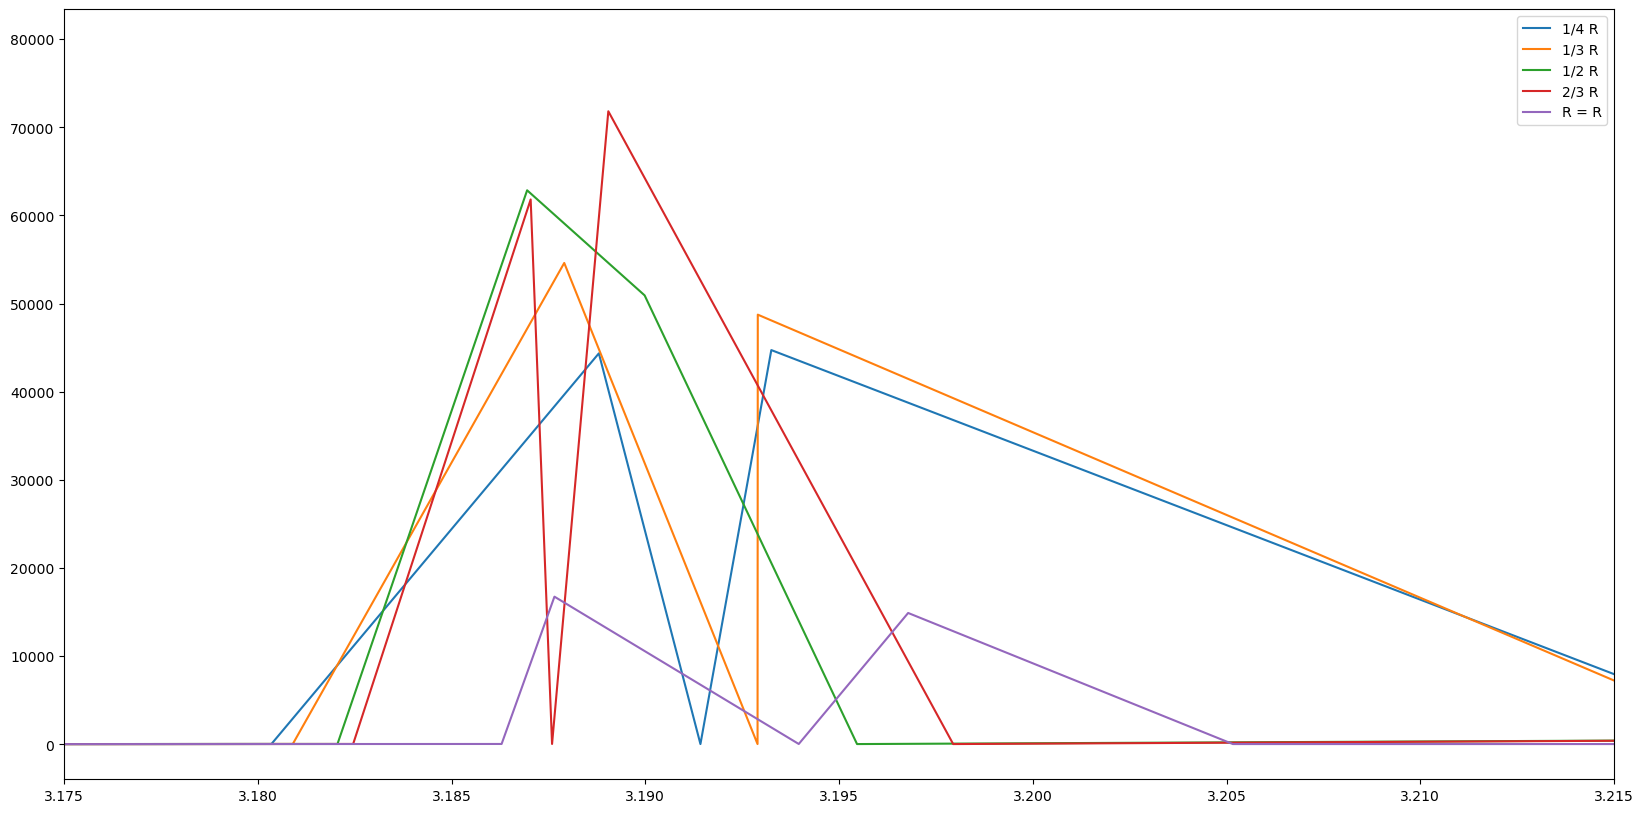

In [37]:
plt.figure(figsize = (20,10))
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(3.175, 3.215)

try gathering the highest-Q points for each radius, and then plotting where those high-Q points end up

(3.39, 3.425)

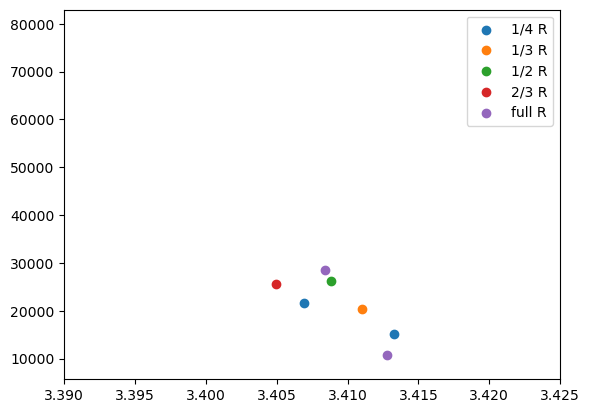

In [43]:
plt.scatter(quarter_R_peaks['freqs'], quarter_R_peaks['Q'], label = '1/4 R')
plt.scatter(third_R_peaks['freqs'], third_R_peaks['Q'], label = '1/3 R')
plt.scatter(half_R_peaks['freqs'], half_R_peaks['Q'], label = '1/2 R')
plt.scatter(twothirds_R_peaks['freqs'], twothirds_R_peaks['Q'], label = '2/3 R')
plt.scatter(full_R_peaks['freqs'], full_R_peaks['Q'], label = 'full R')
plt.legend()
plt.xlim(3.39, 3.425)

In [ ]:
quarter_R_peaks